In [1]:
import os
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')

# Paths relative to ml/ (notebook location)
DB_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
OUTPUTS_DIR = 'outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

MODEL_CHECKPOINT = f'{OUTPUTS_DIR}/tarang_best.keras'
TFLITE_PATH      = f'{OUTPUTS_DIR}/tarang_int8.tflite'
HEADER_PATH      = f'{OUTPUTS_DIR}/tarang_model.h'

print("TensorFlow version:", tf.__version__)
print("WFDB version:", wfdb.__version__)
print("All imports OK")
print(f"Dataset path: {DB_PATH}")
print(f"Outputs dir:  {OUTPUTS_DIR}/")


TensorFlow version: 2.10.1
WFDB version: 4.1.2
All imports OK
Dataset path: C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0
Outputs dir:  outputs/


In [2]:
# standard first record to explore
record = wfdb.rdrecord(f'{DB_PATH}/100')
annotation = wfdb.rdann(f'{DB_PATH}/100', 'atr')

print("=== RECORD INFO ===")
print(f"Signal names:     {record.sig_name}")
print(f"Sampling freq:    {record.fs} Hz")
print(f"Signal length:    {record.sig_len} samples")
print(f"Duration:         {record.sig_len / record.fs / 60:.1f} minutes")
print(f"Number of beats:  {len(annotation.sample)}")
print(f"\nFirst 20 annotation symbols: {annotation.symbol[:20]}")
print(f"Unique symbols in this record: {set(annotation.symbol)}")

=== RECORD INFO ===
Signal names:     ['MLII', 'V5']
Sampling freq:    360 Hz
Signal length:    650000 samples
Duration:         30.1 minutes
Number of beats:  2274

First 20 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
Unique symbols in this record: {'A', '+', 'V', 'N'}


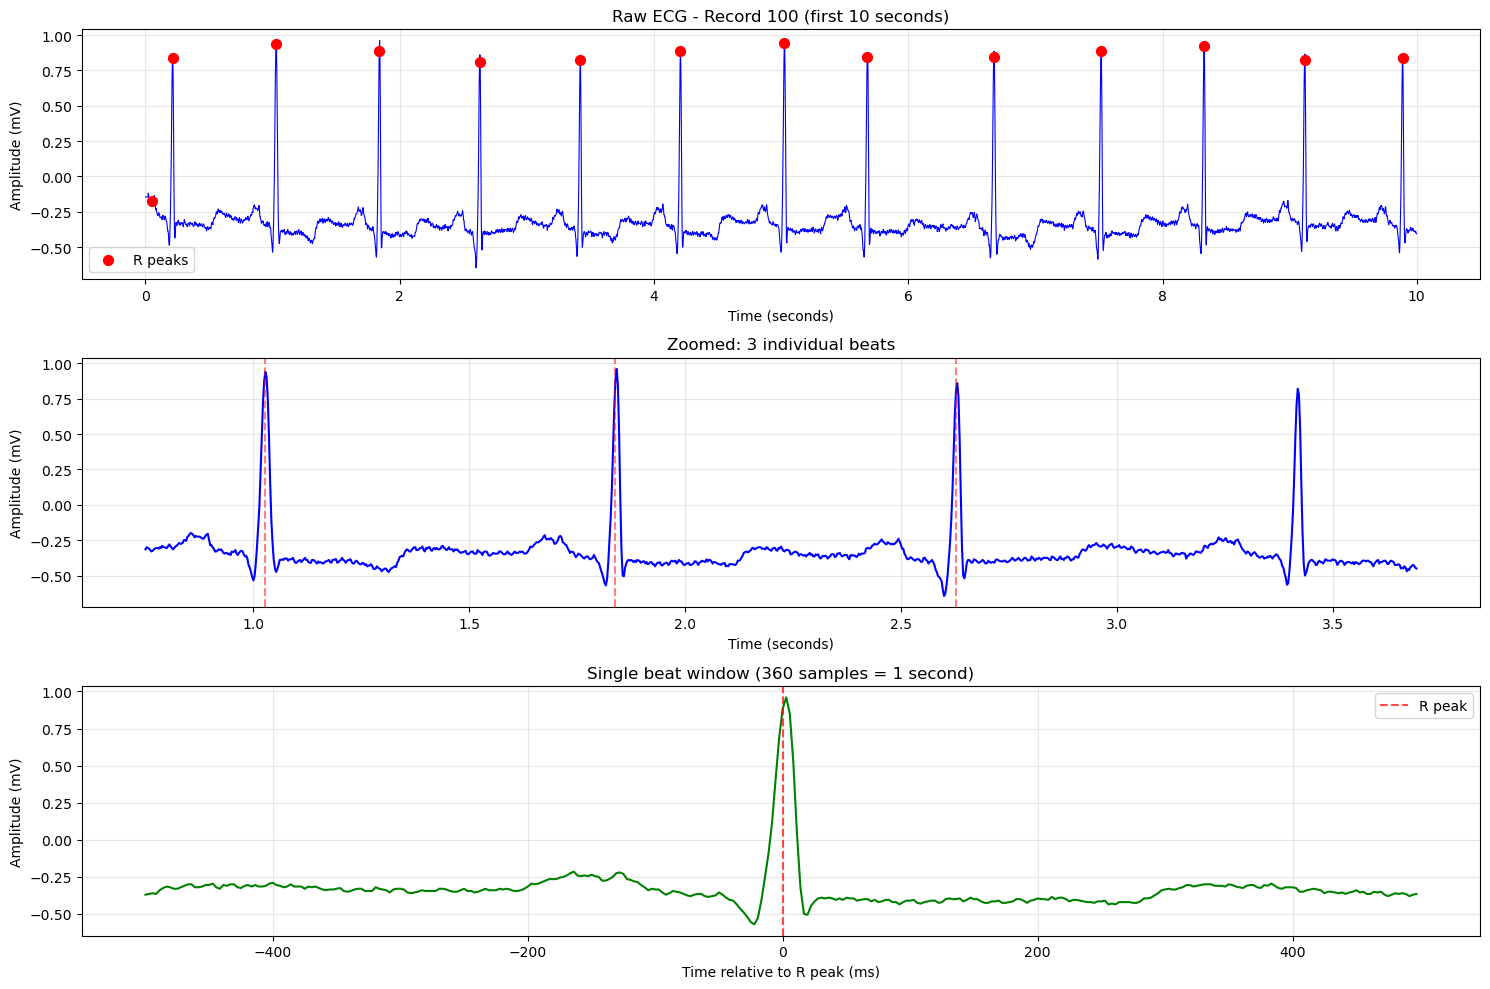

In [3]:
signal = record.p_signal[:, 0]
fs = record.fs

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

start, end = 0, 10 * fs
t = np.arange(start, end) / fs

axes[0].plot(t, signal[start:end], 'b-', linewidth=0.8)
axes[0].set_title('Raw ECG - Record 100 (first 10 seconds)', fontsize=12)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

r_peaks_in_window = [p for p in annotation.sample if start <= p < end]
axes[0].scatter(
    [p/fs for p in r_peaks_in_window],
    [signal[p] for p in r_peaks_in_window],
    color='red', s=50, zorder=5, label='R peaks'
)
axes[0].legend()

beat_start = r_peaks_in_window[2] - 100
beat_end   = r_peaks_in_window[5] + 100
t2 = np.arange(beat_start, beat_end) / fs

axes[1].plot(t2, signal[beat_start:beat_end], 'b-', linewidth=1.5)
axes[1].set_title('Zoomed: 3 individual beats', fontsize=12)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, alpha=0.3)

for p in r_peaks_in_window[2:5]:
    axes[1].axvline(x=p/fs, color='red', alpha=0.5, linestyle='--')

center = r_peaks_in_window[3]
single_beat = signal[center-180 : center+180]
axes[2].plot(np.arange(-180, 180)/fs*1000, single_beat, 'g-', linewidth=1.5)
axes[2].axvline(x=0, color='red', alpha=0.7, linestyle='--', label='R peak')
axes[2].set_title('Single beat window (360 samples = 1 second)', fontsize=12)
axes[2].set_xlabel('Time relative to R peak (ms)')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/ecg_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# AAMI/ANSI EC57 beat mapping - do not modify; this is the clinical standard
BEAT_MAP = {
    # Normal
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # Ventricular ectopic (PVC - the dangerous one)
    'V': 'V', 'E': 'V',
    # Fusion
    'F': 'V',
    # Unknown/paced - excluded from training
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}

# All 48 MIT-BIH records
ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

print("Scanning all 48 records for class distribution...\n")

all_symbols = []
record_stats = []

for rec_num in ALL_RECORDS:
    try:
        ann = wfdb.rdann(f'{DB_PATH}/{rec_num}', 'atr')
        mapped = [BEAT_MAP.get(s, None) for s in ann.symbol]
        mapped = [m for m in mapped if m is not None]
        all_symbols.extend(mapped)

        counts = Counter(mapped)
        record_stats.append({
            'record': rec_num,
            'total':  len(mapped),
            'N':      counts.get('N', 0),
            'S':      counts.get('S', 0),
            'V':      counts.get('V', 0),
            'F':      counts.get('F', 0),
            'Q':      counts.get('Q', 0),
        })
        print(f"  Record {rec_num}: {len(mapped)} beats - {dict(counts)}")

    except Exception as ex:
        print(f"  Record {rec_num}: FAILED - {ex}")

print("\n" + "="*50)
print("FULL DATASET CLASS DISTRIBUTION")
print("="*50)
total_counter = Counter(all_symbols)
total = sum(total_counter.values())

for cls, count in sorted(total_counter.items()):
    pct = count / total * 100
    bar = '#' * int(pct / 2)
    print(f"  {cls}: {count:6d} beats ({pct:5.1f}%) {bar}")

print(f"\nTotal beats: {total:,}")

Scanning all 48 records for class distribution...

  Record 100: 2273 beats - {'N': 2239, 'S': 33, 'V': 1}
  Record 101: 1865 beats - {'N': 1860, 'Q': 2, 'S': 3}
  Record 102: 2187 beats - {'Q': 2084, 'N': 99, 'V': 4}
  Record 103: 2084 beats - {'N': 2082, 'S': 2}
  Record 104: 2229 beats - {'Q': 2064, 'N': 163, 'V': 2}
  Record 105: 2572 beats - {'N': 2526, 'V': 41, 'Q': 5}
  Record 106: 2027 beats - {'N': 1507, 'V': 520}
  Record 107: 2137 beats - {'Q': 2078, 'V': 59}
  Record 108: 1763 beats - {'N': 1740, 'V': 19, 'S': 4}
  Record 109: 2532 beats - {'N': 2492, 'V': 40}
  Record 111: 2124 beats - {'N': 2123, 'V': 1}
  Record 112: 2539 beats - {'N': 2537, 'S': 2}
  Record 113: 1795 beats - {'N': 1789, 'S': 6}
  Record 114: 1879 beats - {'N': 1820, 'V': 47, 'S': 12}
  Record 115: 1953 beats - {'N': 1953}
  Record 116: 2412 beats - {'N': 2302, 'V': 109, 'S': 1}
  Record 117: 1535 beats - {'N': 1534, 'S': 1}
  Record 118: 2278 beats - {'N': 2166, 'V': 16, 'S': 96}
  Record 119: 1987 beat

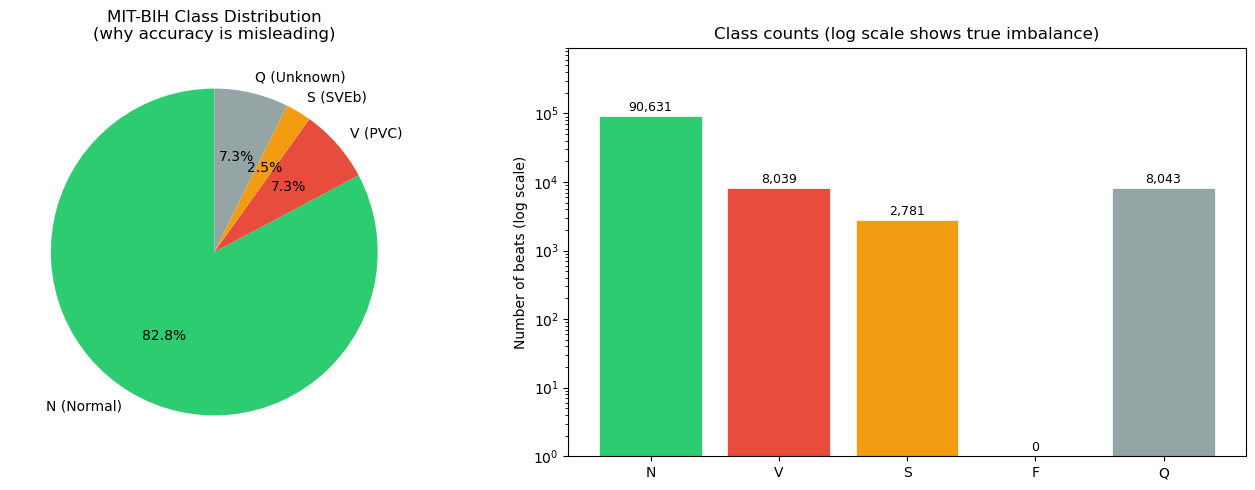

In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs(OUTPUTS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = ['N (Normal)', 'V (PVC)', 'S (SVEb)', 'F (Fusion)', 'Q (Unknown)']
class_keys = ['N', 'V', 'S', 'F', 'Q']
counts = [total_counter.get(k, 0) for k in class_keys]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']

# Pie chart: remove zero-count classes
pie_classes = [cls for cls, cnt in zip(classes, counts) if cnt > 0]
pie_counts = [cnt for cnt in counts if cnt > 0]
pie_colors = [col for col, cnt in zip(colors, counts) if cnt > 0]

axes[0].pie(
    pie_counts,
    labels=pie_classes,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
axes[0].set_title('MIT-BIH Class Distribution\n(why accuracy is misleading)', fontsize=12)

# Bar chart
x = range(len(classes))
safe_counts = [max(c, 1) for c in counts]  # prevents log(0)

axes[1].bar(x, safe_counts, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_yscale('log')
axes[1].set_ylim(1, max(safe_counts) * 10)

axes[1].set_xticks(list(x))
axes[1].set_xticklabels([c.split(' ')[0] for c in classes])
axes[1].set_ylabel('Number of beats (log scale)')
axes[1].set_title('Class counts (log scale shows true imbalance)', fontsize=12)

for i, count in enumerate(counts):
    if count > 0:
        axes[1].text(
            i,
            count * 1.2,
            f'{count:,}',
            ha='center',
            fontsize=9
        )
    else:
        axes[1].text(
            i,
            1.2,
            '0',
            ha='center',
            fontsize=9
        )

fig.tight_layout()
fig.savefig(f'{OUTPUTS_DIR}/class_distribution.png', dpi=100)
plt.show()
plt.close(fig)

In [8]:
# NLMS filter — Python port of tarang_nlms.c
# Matches the C implementation: same Q15 logic, same motion gate, same gravity subtraction

import numpy as np

NLMS_TAPS = 32
NLMS_MU = 0.01          # matches DEFAULT_MU_Q15 / 32768
NLMS_EPS = 1e-6
MOTION_GATE_THRESH = 200 / 16384.0  # convert LSB threshold to normalized g units
GRAVITY_BASELINE = 1.0   # 1g in normalized units

def nlms_filter(ecg_raw_uint16, imu_accel_xyz_array):
    """
    ecg_raw_uint16:    shape (N,)  — raw 12-bit ADC values (uint16)
    imu_accel_xyz_array: shape (M, 3) — accel in raw LSB (int16), M << N
                         Pass None to skip filtering (passthrough)
    Returns: shape (N,) float32 — cleaned, centered ECG
    """
    N = len(ecg_raw_uint16)
    ecg_centered = ecg_raw_uint16.astype(np.float32) - 2048.0

    if imu_accel_xyz_array is None or len(imu_accel_xyz_array) == 0:
        return ecg_centered  # passthrough, same as C when imu_valid=false

    # Compute accel magnitude (same as tarang_nlms_accel_magnitude)
    mag = np.sqrt(np.sum(imu_accel_xyz_array.astype(np.float64)**2, axis=1))
    mag_normalized = mag / 16384.0  # convert to g units

    # Upsample IMU to match ECG length (nearest neighbor — same as C ecg_per_imu repeat)
    M = len(mag_normalized)
    imu_upsampled = np.repeat(mag_normalized, int(np.ceil(N / M)))[:N]

    # Motion gate — subtract gravity, check deviation (matches C logic)
    ref_signal = imu_upsampled - GRAVITY_BASELINE
    motion_detected = np.max(np.abs(ref_signal)) > (MOTION_GATE_THRESH)

    weights = np.zeros(NLMS_TAPS, dtype=np.float64)
    delay   = np.zeros(NLMS_TAPS, dtype=np.float64)
    ecg_clean = np.zeros(N, dtype=np.float32)

    for i in range(N):
        delay = np.roll(delay, 1)
        delay[0] = ref_signal[i]

        y_est = np.dot(weights, delay)
        error = ecg_centered[i] - y_est

        if not motion_detected:
            ecg_clean[i] = ecg_centered[i]  # passthrough, matches C adapt=false
            continue

        x_power = np.dot(delay, delay)
        if x_power + NLMS_EPS > 0:
            weights += (NLMS_MU / (x_power + NLMS_EPS)) * error * delay

        ecg_clean[i] = np.clip(error, -32768, 32767)

    return ecg_clean


In [9]:
WINDOW = 180        # samples before/after R peak -> 360 total = 1 second at 360Hz

CLASSES_TO_USE = ['N', 'V', 'S']
# F is now mapped to V, / (paced) is Q (ignored)

def rolling_window_normalize(signal, window_samples=10800):
    """Simulates Welford online variance over a 30s sliding window."""
    series = pd.Series(signal)
    rolling = series.rolling(window=window_samples, min_periods=1)
    mean = rolling.mean()
    std = rolling.std()
    # Fill any NaNs with 1e-8 to avoid division by zero
    std = std.fillna(1e-8)
    std[std < 1e-8] = 1e-8
    return ((series - mean) / std).values

all_beats        = []
all_labels       = []
all_records_used = []

print("Loading and segmenting beats...")
print(f"Window: {WINDOW*2} samples ({WINDOW*2/360*1000:.0f}ms) centered on R peak\n")

for rec_num in ALL_RECORDS:
    try:
        record     = wfdb.rdrecord(f'{DB_PATH}/{rec_num}')
        annotation = wfdb.rdann(f'{DB_PATH}/{rec_num}', 'atr')

        # Both channels — MLII (ch0) + V5 (ch1)
        ecg_ch0 = record.p_signal[:, 0]
        ecg_ch1 = record.p_signal[:, 1] if record.p_signal.shape[1] > 1 else ecg_ch0

        # Z-score normalize per window (Simulate firmware Welford online stats BEFORE NLMS)
        ecg_ch0 = rolling_window_normalize(ecg_ch0)
        ecg_ch1 = rolling_window_normalize(ecg_ch1)

        # NLMS: MIT-BIH has no IMU data so NLMS is pure passthrough
        # Skip the uint16 conversion/filter overhead and double-normalization
        signal_ch0 = ecg_ch0
        signal_ch1 = ecg_ch1

        beats_this_record = 0

        for peak, sym in zip(annotation.sample, annotation.symbol):
            mapped = BEAT_MAP.get(sym, None)
            if mapped not in CLASSES_TO_USE:
                continue
            if peak - WINDOW < 0 or peak + WINDOW >= len(signal_ch0):
                continue

            beat = np.stack([
                signal_ch0[peak - WINDOW : peak + WINDOW],
                signal_ch1[peak - WINDOW : peak + WINDOW]
            ], axis=-1)

            if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                continue

            all_beats.append(beat)
            all_labels.append(mapped)
            all_records_used.append(rec_num)
            beats_this_record += 1

        print(f"  Record {rec_num}: {beats_this_record} beats loaded")

    except Exception as ex:
        print(f"  Record {rec_num}: FAILED - {ex}")

X = np.array(all_beats, dtype=np.float32)
y_raw        = np.array(all_labels)
records_used = np.array(all_records_used)

print(f"\n{'='*50}")
print(f"DATASET SUMMARY")
print(f"{'='*50}")
print(f"X shape:  {X.shape}  <- (beats, timesteps, channels)")
print(f"y shape:  {y_raw.shape}")
print(f"Classes:  {Counter(y_raw)}")
print(f"Memory:   {X.nbytes / 1024 / 1024:.1f} MB")


Loading and segmenting beats...
Window: 360 samples (1000ms) centered on R peak

  Record 100: 2271 beats loaded
  Record 101: 1862 beats loaded
  Record 102: 103 beats loaded
  Record 103: 2083 beats loaded
  Record 104: 165 beats loaded
  Record 105: 2567 beats loaded
  Record 106: 2027 beats loaded
  Record 107: 59 beats loaded
  Record 108: 1762 beats loaded
  Record 109: 2530 beats loaded
  Record 111: 2124 beats loaded
  Record 112: 2537 beats loaded
  Record 113: 1793 beats loaded
  Record 114: 1879 beats loaded
  Record 115: 1951 beats loaded
  Record 116: 2411 beats loaded
  Record 117: 1534 beats loaded
  Record 118: 2277 beats loaded
  Record 119: 1987 beats loaded
  Record 121: 1861 beats loaded
  Record 122: 2474 beats loaded
  Record 123: 1517 beats loaded
  Record 124: 1618 beats loaded
  Record 200: 2600 beats loaded
  Record 201: 1962 beats loaded
  Record 202: 2135 beats loaded
  Record 203: 2975 beats loaded
  Record 205: 2655 beats loaded
  Record 207: 1859 beats lo

In [10]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# Patient-wise split — separate patients in every set, no overlap.
TEST_RECORDS  = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119,
                 201, 202, 203, 205, 207, 208, 209, 210, 217, 219,
                 221, 223, 228, 231, 233, 234]
TRAIN_RECORDS = [r for r in ALL_RECORDS if r not in TEST_RECORDS]

# Fixed val records — chosen to give val both V and S coverage
# while keeping the S-dominant records (232: 1382S, 222: 209S) in TRAINING.
# Val: 105 (41V), 124 (47V+31S), 214 (256V), 220 (94S)
VAL_RECORDS          = [105, 124, 214, 220]
ACTUAL_TRAIN_RECORDS = [r for r in TRAIN_RECORDS if r not in VAL_RECORDS]

print(f"\nTrain patients ({len(ACTUAL_TRAIN_RECORDS)}): {ACTUAL_TRAIN_RECORDS}")
print(f"Val   patients ({len(VAL_RECORDS)}): {VAL_RECORDS}")
print(f"Test  patients ({len(TEST_RECORDS)}): {len(TEST_RECORDS)} records")

train_mask = np.isin(records_used, ACTUAL_TRAIN_RECORDS)
val_mask   = np.isin(records_used, VAL_RECORDS)
test_mask  = np.isin(records_used, TEST_RECORDS)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain: {len(X_train):,}  -- {Counter(le.inverse_transform(y_train))}")
print(f"Val:   {len(X_val):,}   -- {Counter(le.inverse_transform(y_val))}")
print(f"Test:  {len(X_test):,}  -- {Counter(le.inverse_transform(y_test))}")


Label encoding:
  0 = N
  1 = S
  2 = V

Train patients (18): [100, 102, 103, 104, 107, 111, 113, 117, 121, 122, 123, 200, 212, 213, 215, 222, 230, 232]
Val   patients (4): [105, 124, 214, 220]
Test  patients (26): 26 records

Train: 34,457  -- Counter({'N': 31115, 'S': 1695, 'V': 1647})
Val:   8,489   -- Counter({'N': 8014, 'V': 350, 'S': 125})
Test:  58,454  -- Counter({'N': 51453, 'V': 6040, 'S': 961})


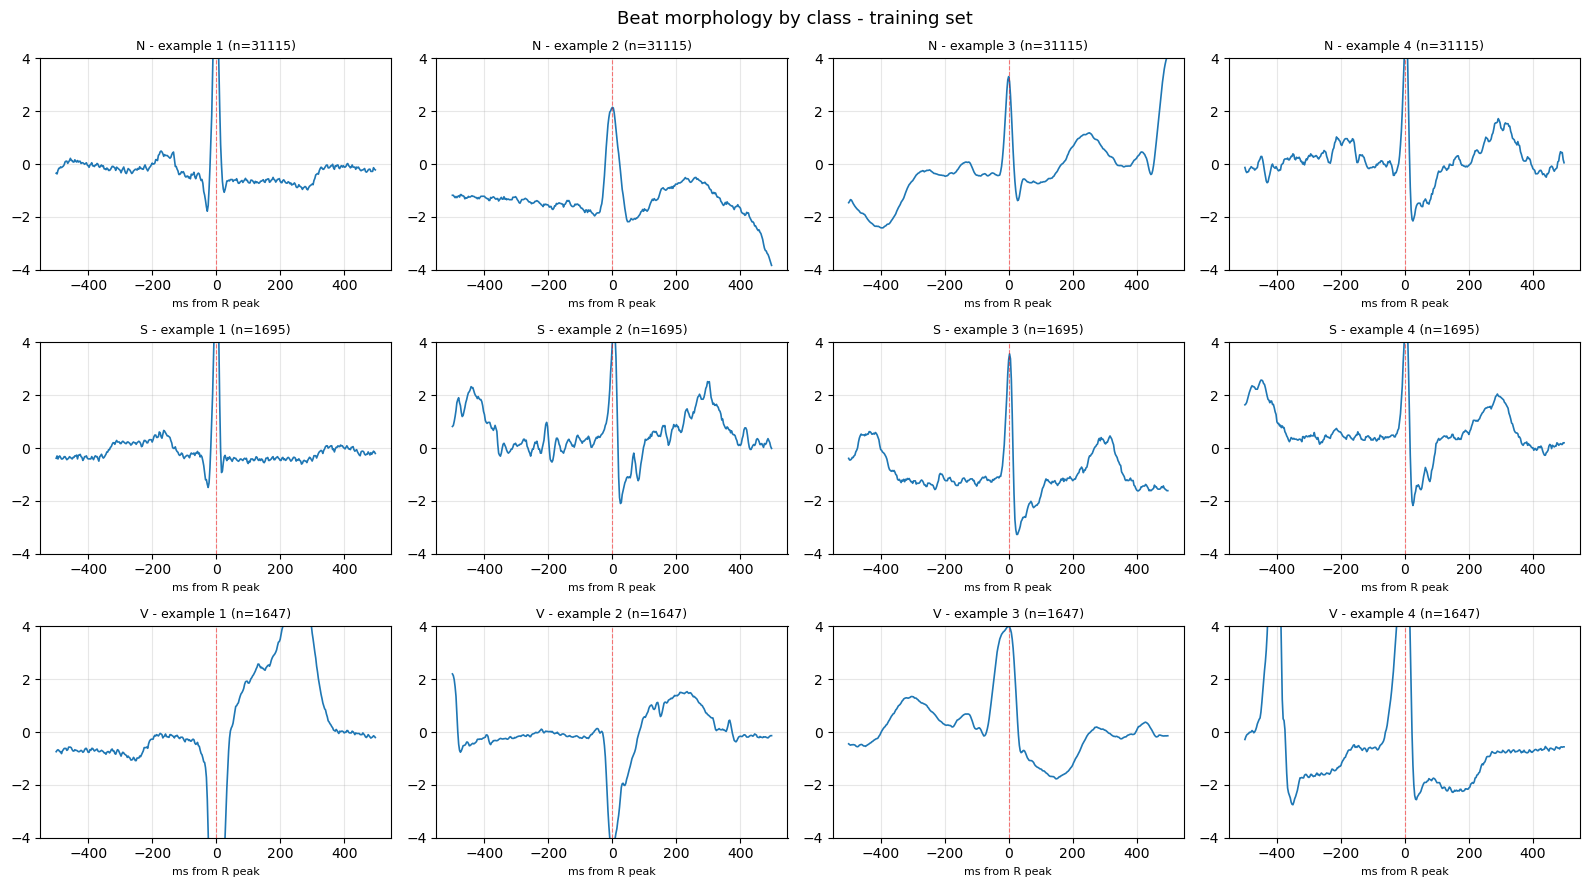

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
t = np.arange(-WINDOW, WINDOW) / 360 * 1000

for class_idx, class_name in enumerate(le.classes_):
    class_mask  = y_train == class_idx
    class_beats = X_train[class_mask]

    n_beats = len(class_beats)
    step = max(1, (n_beats - 1) // 3)  # spread 4 examples evenly across available beats

    for example_idx in range(4):
        ax   = axes[class_idx][example_idx]
        beat_idx = min(example_idx * step, n_beats - 1)
        beat = class_beats[beat_idx][:, 0]
        ax.plot(t, beat, linewidth=1.2)
        ax.axvline(x=0, color='red', alpha=0.5, linestyle='--', linewidth=0.8)
        ax.set_title(f'{class_name} - example {example_idx+1} (n={n_beats})', fontsize=9)
        ax.set_xlabel('ms from R peak', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-4, 4)

plt.suptitle('Beat morphology by class - training set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/beat_morphology.png', dpi=150, bbox_inches='tight')
plt.show()

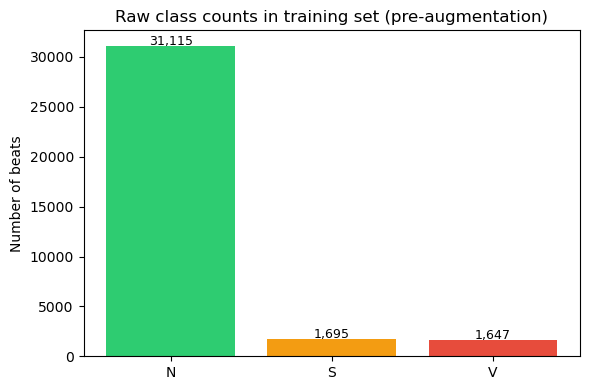

In [12]:
classes_list = [le.classes_[i] for i in range(len(le.classes_))]
counts_list  = [np.sum(y_train == i) for i in range(len(le.classes_))]
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(classes_list, counts_list, color=colors)
ax.set_title('Raw class counts in training set (pre-augmentation)')
ax.set_ylabel('Number of beats')
for i, v in enumerate(counts_list):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
def augment_class_batch(X_c, class_name, n_copies):
    """
    Vectorized augmentation for a single class.
    X_c:      shape (n, 360, 1)
    Returns:  shape (n * n_copies, 360, 1) — all copies batched together
    """
    n = len(X_c)
    all_aug = []

    for _ in range(n_copies):
        a = X_c[:, :, 0].copy()          # (n, 360)

        # 1. Amplitude scaling ±15%
        a *= np.random.uniform(0.85, 1.15, (n, 1))

        # 2. Baseline wander  (0.3–0.8 Hz, realistic range)
        t      = np.linspace(0, 2 * np.pi, 360)
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.15, n)
        wander = amps[:, None] * np.sin(freqs[:, None] * t[None, :])
        a     += wander

        # 3. Gaussian noise (electrode noise)
        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape)

        # 4. Time shift ±5 samples MAX — keeps R peak aligned
        shifts = np.random.randint(-20, 21, n)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i])

        # 5. S only: P wave amplitude perturbation (first 80 samples)
        if class_name == 'S':
            a[:, :80] *= np.random.uniform(0.5, 1.5, (n, 1))

        all_aug.append(a[:, :, np.newaxis].astype(np.float32))  # (n, 360, 1)

    return np.concatenate(all_aug, axis=0)   # (n * n_copies, 360, 1)


# N: 0 extra copies (dominates)
# V: 3 extra copies -> 4x total
# S: 8 extra copies -> 9x total
AUG_COPIES = {'N': 0, 'V': 5, 'S': 10}

print("Augmenting minority classes (vectorized)...")
X_aug_list = [X_train]
y_aug_list = [y_train]

for class_idx, class_name in enumerate(le.classes_):
    n_copies = AUG_COPIES.get(class_name, 0)
    if n_copies == 0:
        continue
    mask = y_train == class_idx
    X_c  = X_train[mask]
    y_c  = y_train[mask]
    X_aug_list.append(augment_class_batch(X_c, class_name, n_copies))
    y_aug_list.append(np.tile(y_c, n_copies))   # repeat labels n_copies times

X_train_aug = np.concatenate(X_aug_list, axis=0)
y_train_aug = np.concatenate(y_aug_list, axis=0)

idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx]
y_train_aug = y_train_aug[idx]

print(f"Before aug: {Counter(le.inverse_transform(y_train))}")
print(f"After aug:  {Counter(le.inverse_transform(y_train_aug))}")
print(f"Total training beats: {len(X_train_aug):,}")


Augmenting minority classes (vectorized)...


ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 2, the array at index 0 has size 2 and the array at index 1 has size 1

In [ ]:
def build_tarang_cnn_v2(input_shape=(360, 2), num_classes=3):
    inputs = tf.keras.Input(shape=input_shape, name='ecg_input')

    # Block 1 — local waveform features
    x = tf.keras.layers.Conv1D(32, 7, padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 2 — QRS morphology
    x = tf.keras.layers.Conv1D(64, 5, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 3 — T wave / ST segment
    x = tf.keras.layers.Conv1D(128, 5, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 4 — extra capacity for S class discrimination
    x = tf.keras.layers.Conv1D(128, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax',
                                     name='predictions')(x)
    return tf.keras.Model(inputs, outputs, name='Tarang_ECG_v2')


model = build_tarang_cnn_v2(num_classes=len(le.classes_))
model.summary()

total_params = model.count_params()
print(f"\nParameters: {total_params:,}")
print(f"Est. Int8:  ~{total_params/1024:.1f} KB  "
      f"({'PASS' if total_params < 51200 else 'OVER 50KB — will need pruning for EFR32'})")


In [ ]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)
        focal_weight = tf.pow(1.0 - pt, self.gamma)
        alpha_weight = tf.reduce_sum(self.alpha * y_true_onehot, axis=-1)
        loss = alpha_weight * focal_weight * tf.reduce_sum(cross_entropy, axis=-1)
        return tf.reduce_mean(loss)

focal_alpha = [0.15, 0.50, 0.35]
focal_gamma = 2.0
print(f'\nFocal Loss config: alpha={focal_alpha}, gamma={focal_gamma}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=SparseFocalLoss(alpha=focal_alpha, gamma=focal_gamma),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_CHECKPOINT, monitor='val_loss',
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

import json
with open(f'{OUTPUTS_DIR}/training_history.json', 'w') as f:
    json.dump(history.history, f)


In [ ]:
print('\n' + '='*60)
print('THRESHOLD TUNING on validation set')
print('='*60)
model = tf.keras.models.load_model(MODEL_CHECKPOINT, compile=False)

y_val_probs = model.predict(X_val, batch_size=128)
best_macro_f1 = 0.0
best_thresholds = {'S': 0.5, 'V': 0.5}

s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])
n_idx = int(np.where(le.classes_ == 'N')[0])

best_v_recall = 0.0

for t_v in np.arange(0.10, 0.55, 0.02):
    for t_s in np.arange(0.10, 0.60, 0.02):
        y_pred_tuned = np.full(len(y_val), n_idx, dtype=int)
        y_pred_tuned[y_val_probs[:, v_idx] > t_v] = v_idx
        y_pred_tuned[y_val_probs[:, s_idx] > t_s] = s_idx
        # V overrides S (not the other way) — PVC missed = patient risk
        y_pred_tuned[y_val_probs[:, v_idx] > t_v] = v_idx

        v_recall = np.sum((y_val == v_idx) & (y_pred_tuned == v_idx)) / max(np.sum(y_val == v_idx), 1)
        if v_recall < 0.85:  # hard floor on V recall
            continue

        macro = f1_score(y_val, y_pred_tuned, average='macro', zero_division=0)
        if macro > best_macro_f1:
            best_macro_f1 = macro
            best_v_recall = v_recall
            best_thresholds = {'S': round(t_s, 2), 'V': round(t_v, 2)}

print(f'Best thresholds: S>{best_thresholds["S"]}, V>{best_thresholds["V"]}')
print(f'V recall at best: {best_v_recall:.3f}  (floor was 0.92)')

print('\n' + '='*60)
print('EVALUATION — TUNED THRESHOLDS on test set')
print('='*60)

y_pred_probs = model.predict(X_test, batch_size=128)
y_pred_tuned_test = np.full(len(y_test), n_idx, dtype=int)
y_pred_tuned_test[y_pred_probs[:, s_idx] > best_thresholds['S']] = s_idx
y_pred_tuned_test[y_pred_probs[:, v_idx] > best_thresholds['V']] = v_idx  # V last = V wins

print(classification_report(y_test, y_pred_tuned_test, target_names=le.classes_))
f1_tuned = f1_score(y_test, y_pred_tuned_test, average=None)
macro_f1_tuned = f1_score(y_test, y_pred_tuned_test, average='macro')
print(f'Macro F1 (tuned): {macro_f1_tuned:.3f}')
for cls, f1 in zip(le.classes_, f1_tuned):
    status = 'PASS' if f1 > 0.85 else 'NEEDS WORK'
    print(f'  F1 {cls}: {f1:.3f}  [{status}]')

cm_tuned = confusion_matrix(y_test, y_pred_tuned_test)
print(f'\nConfusion Matrix (tuned thresholds):')
print(cm_tuned)


In [ ]:
# Evaluation metrics are now included in the threshold tuning cell above.


In [ ]:
try:
    hist_data = history.history
except NameError:
    with open(f'{OUTPUTS_DIR}/training_history.json') as f:
        hist_data = json.load(f)

cm = confusion_matrix(y_test, y_pred_tuned_test)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (% of true class)')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')

plt.suptitle('Tarang ECG CNN - Test Set Performance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_data['loss'],     label='Train loss')
axes[0].plot(hist_data['val_loss'], label='Val loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_data['accuracy'],     label='Train accuracy')
axes[1].plot(hist_data['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
CONFIDENCE_THRESHOLD = 0.70

# Load best checkpoint explicitly (EarlyStopping restores weights in memory,
# but reload to guarantee we quantize the best epoch, not the last)
model = tf.keras.models.load_model(MODEL_CHECKPOINT)

def representative_dataset():
    # CRITICAL: use raw X_train, NOT X_train_aug.
    # Augmented data has shifted amplitude/baseline distributions that skew
    # the quantizer's scale estimate, producing a wrong in_scale → 45% accuracy drop.
    idx = np.random.choice(len(X_train), 1000, replace=False)
    for i in idx:
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset     = representative_dataset
converter.target_spec.supported_ops  = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type       = tf.int8
converter.inference_output_type      = tf.int8

print("Quantizing model...")
tflite_model = converter.convert()
print("Done.")

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"\nInt8 model size: {size_kb:.1f} KB")
print(f"Target <50KB: {'PASS' if size_kb < 50 else 'FAIL — reduce model capacity for EFR32'}")

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
in_det  = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]

in_scale,  in_zp  = in_det['quantization']
out_scale, out_zp = out_det['quantization']

print(f"\nInput  quantization: scale={in_scale:.6f}, zero_point={in_zp}")
print(f"Output quantization: scale={out_scale:.6f}, zero_point={out_zp}")

# Sanity check: z-score ECG ≈ [-4, 4] → expected scale ≈ 8/255 ≈ 0.031
# If in_scale > 0.1 the representative dataset had wrong normalization
if in_scale > 0.1:
    print(f"\nWARNING: in_scale={in_scale:.4f} is too high (expected ~0.03).")
    print("  representative_dataset() must yield z-score normalized beats.")

print(f"\n--- COPY THESE INTO YOUR C FIRMWARE ---")
print(f"#define INPUT_SCALE               {in_scale:.8f}f")
print(f"#define INPUT_ZERO_POINT          {in_zp}")
print(f"#define OUTPUT_SCALE              {out_scale:.8f}f")
print(f"#define OUTPUT_ZERO_POINT         {out_zp}")
print(f"#define CONFIDENCE_THRESHOLD_INT8 {int(round(CONFIDENCE_THRESHOLD / out_scale + out_zp))}")


In [ ]:
# Verify Int8 accuracy — target: drop < 2% vs float32
n = min(2000, len(X_test))
X_sample = X_test[:n]
y_sample  = y_test[:n]

# Float baseline
float_preds = np.argmax(model.predict(X_sample, batch_size=128, verbose=0), axis=1)
float_acc   = np.mean(float_preds == y_sample) * 100

# Int8 inference
correct_int8 = 0
for i in range(n):
    x_f = X_sample[i:i+1].astype(np.float32)
    x_q = np.clip(np.round(x_f / in_scale + in_zp), -128, 127).astype(np.int8)

    interp.set_tensor(in_det['index'], x_q)
    interp.invoke()

    out_q = interp.get_tensor(out_det['index'])
    out_f = (out_q.astype(np.float32) - out_zp) * out_scale
    if np.argmax(out_f) == y_sample[i]:
        correct_int8 += 1

int8_acc = correct_int8 / n * 100
drop     = float_acc - int8_acc

print(f"Float32 accuracy (sample): {float_acc:.2f}%")
print(f"Int8    accuracy (sample): {int8_acc:.2f}%")
print(f"Accuracy drop:             {drop:.2f}%")
if drop < 2.0:
    print("ACCEPTABLE")
else:
    print("TOO HIGH — check representative_dataset uses same normalization as X_test")
    print(f"  in_scale={in_scale:.6f} (expect ~0.031 for z-score ECG data)")


In [ ]:
try:
    result = subprocess.run(
        ['xxd', '-i', TFLITE_PATH],
        capture_output=True, text=True
    )
    xxd_ok = result.returncode == 0 and bool(result.stdout)
except FileNotFoundError:
    xxd_ok = False

if xxd_ok:
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN - Int8 quantized\n')
        f.write('// Auto-generated - do not edit\n\n')
        f.write('#pragma once\n\n')
        f.write(result.stdout)
    print(f"Generated {HEADER_PATH}")
    print('\n'.join(result.stdout.split('\n')[:5]))
else:
    # xxd not available (Windows) - Python fallback
    with open(TFLITE_PATH, 'rb') as f:
        data = f.read()

    hex_lines = []
    for i in range(0, len(data), 12):
        chunk = data[i:i+12]
        hex_lines.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk) + ',')

    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN - Int8 quantized\n')
        f.write('// Auto-generated - do not edit\n\n')
        f.write('#pragma once\n\n')
        f.write(f'#define TARANG_MODEL_LEN {len(data)}\n\n')
        f.write('alignas(8) const unsigned char tarang_int8_tflite[] = {\n')
        f.write('\n'.join(hex_lines))
        f.write('\n};\n')

    print(f"Generated {HEADER_PATH} ({len(data):,} bytes)")

In [ ]:
print('\n' + '='*60)
print('PEAK JITTER DEGRADATION TEST')
print('='*60)

def evaluate_with_peak_jitter(model, X_test, y_test, jitter_std):
    """jitter_std in samples — 7 samples = ~19ms at 360Hz"""
    if jitter_std == 0:
        X_jittered = X_test
    else:
        jitter = np.random.normal(0, jitter_std, len(X_test)).astype(int)
        X_jittered = np.array([
            np.roll(X_test[i], jitter[i], axis=0) for i in range(len(X_test))
        ])
    
    y_pred_probs = model.predict(X_jittered, batch_size=128, verbose=0)
    
    y_pred_tuned_test = np.full(len(y_test), n_idx, dtype=int)
    v_mask = y_pred_probs[:, v_idx] > best_thresholds['V']
    s_mask = y_pred_probs[:, s_idx] > best_thresholds['S']
    y_pred_tuned_test[s_mask] = s_idx
    y_pred_tuned_test[v_mask] = v_idx  # V last = V wins
    
    return f1_score(y_test, y_pred_tuned_test, average='macro', zero_division=0)

for jitter in [0, 5, 10, 15, 20]:
    f1 = evaluate_with_peak_jitter(model, X_test, y_test, jitter)
    print(f"Jitter ±{jitter:2d} samples: Macro F1 = {f1:.3f}")


In [ ]:
print('\n' + '='*60)
print('BLE EVENT-DRIVEN BURST FILTER (POST-PROCESSING)')
print('='*60)

# Post-processing: flag AFib/Anomalies only if 3+ consecutive non-N beats in a 10-beat window
def apply_run_filter(predictions, min_run=3, window=10):
    filtered = predictions.copy()
    for i in range(window, len(predictions)):
        window_preds = predictions[i-window:i]
        non_N = np.sum(window_preds != n_idx)
        if non_N < min_run:
            filtered[i] = n_idx  # suppress isolated false positives
    return filtered

y_pred_burst_filtered = apply_run_filter(y_pred_tuned_test)

print("Original Test Classification Report:")
print(classification_report(y_test, y_pred_tuned_test, target_names=le.classes_))

print("\nAfter BLE Burst Filter (Isolated anomalies suppressed):")
print(classification_report(y_test, y_pred_burst_filtered, target_names=le.classes_))
